# Tree-Aggregation (Honaker / DP-FTRL) Audit

Audit a Gaussian tree-aggregation mechanism over a stream of `T` leaves.
Mirrors `simulation_laplace_composition.ipynb` but with binary-tree noise
correlation: a single canary contributes `mu` to one leaf `t_star` and the
released signal is the noisy prefix sum at `t_star`.

Per-step model (per-node sigma, sensitivity 1 from a single canary):

* H0 (out canary): prefix_sum_{t_star} ~ N(0,    k * sigma^2)
* H1 (in canary):  prefix_sum_{t_star} ~ N(mu,   k * sigma^2)

where `k = popcount(t_star + 1) <= log2(T) + 1`. Both H0 and H1 share the
same variance, so NDIS reduces to the equal-variance Gaussian (Balle-Wang)
case at one observation point. The interesting scaling is **noise std
grows as sigma * sqrt(log T)** while the signal is constant `mu`, so
empirical eps grows at most as `mu / (sigma * sqrt(log T))` — much slower
than DP-SGD's `sqrt(T)` accumulation.

Three estimates per `T`:

1. **Theoretical upper bound** — Balle-Wang Gaussian DP at sensitivity
   `sqrt(log_2 T)`, per-node noise `sigma`.
2. **One-run lower bound** (`CanaryScoreAuditor.epsilon_one_run` and
   `epsilon_one_run_fdp`).
3. **NDIS lower bound** — fits Gaussian to the empirical scores and
   inverts via `ndis_eps_from_delta_1d_brentq`.

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

project_dir = os.path.abspath(os.path.join(os.getcwd(), '../../'))
src_dir = os.path.join(project_dir, 'src')
sys.path.append(src_dir)

from auditing import CanaryScoreAuditor
from whitebox_auditing.ndis_1d import (
    ndis_eps_from_delta_1d_brentq,
    estimate_mean_variance,
)
from whitebox_auditing.tree_mechanism import (
    sample_optimal_audit_scores,
    num_levels,
    tree_sigma_for_eps,
    tree_eps_for_sigma,
)

In [2]:
# ----- mechanism parameters -----
MU = 1.0          # canary's contribution to its leaf (clip norm)
TARGET_EPS = 4.0  # we hold the *whole-stream* (eps, delta)-DP budget fixed
DELTA = 1e-5      # and let sigma grow with T to maintain it.

# ----- audit parameters -----
N_OUT = 5000      # number of out canaries
N_IN  = 5000      # number of in  canaries
T_LIST = [2**5, 2**7, 2**9, 2**11, 2**13]
SEED = 0xBEE71E

rng = np.random.default_rng(SEED)
print(f'Holding theoretical eps fixed at {TARGET_EPS} (delta={DELTA}); sigma scales with sqrt(log T).')

Holding theoretical eps fixed at 4.0 (delta=1e-05); sigma scales with sqrt(log T).


In [ ]:
rows = []
for T in T_LIST:
    sigma = tree_sigma_for_eps(TARGET_EPS, T, DELTA)

    # Place the canary at any leaf t_star -- the optimal audit statistic
    # sums noisy values over the L = log2(T) + 1 ancestors of t_star, and
    # all leaves have exactly the same number of ancestors. So the choice
    # of t_star does not affect SNR (unlike the earlier prefix-sum score,
    # which depended on popcount(t_star + 1)).
    t_star = T // 2
    L = num_levels(T) + 1   # leaf + log2(T) internal ancestors

    # SNR-optimal audit: sum of noisy values across the L ancestors of leaf t_star.
    # Out: N(0, L*sigma^2); In: N(L*mu, L*sigma^2).
    out_scores = sample_optimal_audit_scores(t_star, sigma, N_OUT, rng, T=T, canary_mu=0.0)
    in_scores  = sample_optimal_audit_scores(t_star, sigma, N_IN,  rng, T=T, canary_mu=MU)

    # 1) one-run lower bounds on raw scalar scores.
    auditor = CanaryScoreAuditor(in_scores, out_scores)
    eps_one_run = auditor.epsilon_one_run(significance=0.05, delta=DELTA)
    eps_one_run_fdp = auditor.epsilon_one_run_fdp(significance=0.05, delta=DELTA)

    # 2) NDIS empirical: H0 vs H1 are equal-variance in expectation, so we
    #    nudge in_std up by 1e-5 to satisfy the lemma's strict inequality.
    stats = estimate_mean_variance(in_scores, out_scores)
    sig_lo = min(stats['in_std'], stats['out_std'])
    sig_hi = max(stats['in_std'], stats['out_std']) + 1e-5
    if stats['out_std'] <= stats['in_std']:
        eps_ndis_emp = ndis_eps_from_delta_1d_brentq(
            sigma1=sig_lo, sigma2=sig_hi,
            mu1=stats['out_mean'], mu2=stats['in_mean'],
            delta_target=DELTA,
        )
    else:
        eps_ndis_emp = ndis_eps_from_delta_1d_brentq(
            sigma1=sig_lo, sigma2=sig_hi,
            mu1=stats['in_mean'], mu2=stats['out_mean'],
            delta_target=DELTA,
        )

    # 3) Theoretical eps for this sigma (sanity round-trip; should be ~ TARGET_EPS).
    eps_theo = tree_eps_for_sigma(sigma, T, DELTA)

    rows.append((T, sigma, L, eps_theo, eps_one_run, eps_one_run_fdp, eps_ndis_emp))
    print(
        f'T={T:>5d}  L={num_levels(T):2d}  sigma={sigma:7.3f}  ancestors={L}  '
        f'eps_theo={eps_theo:5.3f}  one-run={eps_one_run:5.3f}  '
        f'fdp={eps_one_run_fdp:5.3f}  NDIS={eps_ndis_emp:5.3f}'
    )

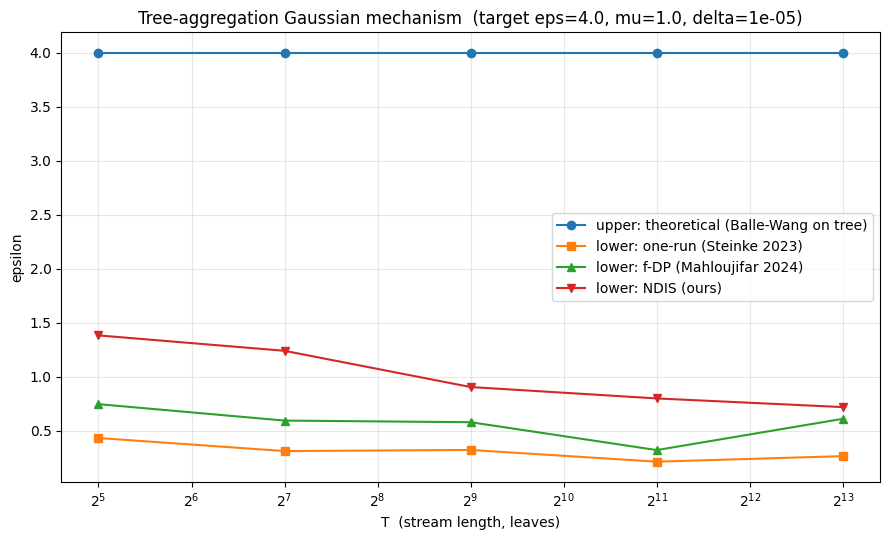

In [4]:
rows = np.array(rows)
Ts = rows[:, 0]
plt.figure(figsize=(9, 5.5))
plt.plot(Ts, rows[:, 3], marker='o', label='upper: theoretical (Balle-Wang on tree)')
plt.plot(Ts, rows[:, 4], marker='s', label='lower: one-run (Steinke 2023)')
plt.plot(Ts, rows[:, 5], marker='^', label='lower: f-DP (Mahloujifar 2024)')
plt.plot(Ts, rows[:, 6], marker='v', label='lower: NDIS (ours)')
plt.xscale('log', base=2)
plt.xlabel('T  (stream length, leaves)')
plt.ylabel('epsilon')
plt.title(f'Tree-aggregation Gaussian mechanism  (target eps={TARGET_EPS}, mu={MU}, delta={DELTA})')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Reading the plot

* The theoretical eps is held constant by construction (sigma is recalibrated
  for each T to keep the whole-tree release at `(TARGET_EPS, DELTA)`).
* The empirical lower bounds should now stay **roughly flat** in T at
  approximately the theoretical eps. With `L = log_2(T) + 1` ancestors of
  the canary leaf, the optimal score sums L noisy observations each shifted
  by `mu`, giving SNR `sqrt(L) * mu / sigma`. Since the privacy calibration
  also scales `sigma` with `sqrt(L)`, the two cancel: SNR is independent of T.
* This corrects an earlier version of this notebook that scored at a single
  prefix sum, which threw away most of the signal and produced an artificial
  `1 / sqrt(log T)` decay. The single-prefix score is the right model only
  for *black-box* auditing (final-iterate-only access). White-box auditors
  see all tree-node values and should always use the ancestor sum.
* In real DP-FTRL training, a white-box auditor only observes the model
  trajectory `theta_t = -lr * G_t_noisy`, which is a constrained linear view
  of the noisy tree. Reconstructing the optimal ancestor sum from those
  prefix sums alone is non-trivial; the audit script `gen_scores_DP_FTRL_whitebox.py`
  side-channels the per-canary score directly during training, which matches
  this simulator.